In [156]:
from src.layers.transformer.ATAT import LightCurveTransformer
from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY,ZTF_TAXONOMY
import pandas as pd

In [157]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5

    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8

    '#2F8B04', # snii 9
    '#7a71f8', # ebew 10
    "#3b3ee7ff", #lpv 11

    "#41708f", # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
     '#00e3ff', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]

colors_hier = [
    #,'#554FCF
    #'#FBAC23', #agn 0
    '#fd31ee',# agn
    '#fd31ee', #qso 1
    '#00e3ff', # EA 2

    '#fd31ee', #yso 3
    '#1bda00',  # snia 4
    '#fd31ee', # cvnova 5
    '#00e3ff',# 6 rrlc  tt
    '#00e3ff',  # 7 rscvn
    '#fd31ee',#'#96034A', #blacar 8
    '#1bda00', # snii 9
    '#00e3ff', # ebew 10
    '#00e3ff', #lpv 11

    '#00e3ff', # cep 12
    '#00e3ff', # rrlab 13
    '#00e3ff', # periodic other 14
    '#60fff3', #dsct 15
    '#1bda00', # snibc 16
    '#1bda00', # slsn 17
    '#1bda00', # tde 18
    '#1bda00', # sniib 19
    '#1bda00', # sniin 20
    '#1bda00', # microlensing 21
    ]

In [158]:
PATH = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/FINAL_v16/'
FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
FP_DATASET ='/home/mdelafuente/ZTF_SSL_Dataset/data/H5_files/BY_PARTITION/200_FF.h5'
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"

DEVICE = 'cuda:2'
TAXONOMY = ZTF_TAXONOMY

In [159]:
from src.exploringtools.ExplorePretraining import ExplorePretraining
from src.exploringtools.InitDataloader import InitDataLoader


test = ExplorePretraining(path_to_config_yaml=PATH,
                    model= LightCurveTransformer,
                    arg_key='lc')
od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'transformer_tab', 'classifier'],rename_keys = ('model.',''), checkpoint_name='pretrain_ckpt')
test.load_backbone_weights(od)
dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_validation_dataset()

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/src/exploringtools/InitBackbone.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serializati

Using checkpoint 4526.ckpt
     - Loaded backbone weights


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2888: RuntimeWarning: invalid value encountered in subtract
  np.interp(X_col_finite, quantiles, self.references_)


In [160]:
X_val, y_val =test.predict(dl.validation_dataset, DEVICE)

device set to cuda:2


  5%|▌         | 21/382 [00:01<00:17, 20.26it/s]

100%|██████████| 382/382 [00:16<00:00, 23.75it/s]


In [161]:
target = y_val
from sklearn.discriminant_analysis import StandardScaler
import umap
import umap.plot
scaler = StandardScaler()
#bokeh.io.output_notebook(INLINE)
umap_args = {'min_dist':0.5}
umap_obj = umap.UMAP(**umap_args)
mapper = umap_obj.fit(scaler.fit_transform(X_val))
hover_data = pd.DataFrame({'index':range(len(X_val)),
                            'label':y_val,
                            })

hover_data['class'] = hover_data.label.map({value:key for key,value in TAXONOMY().items()})

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'UMAP Dimensionality Reduction Before Pretraining the Embedding Space'}>

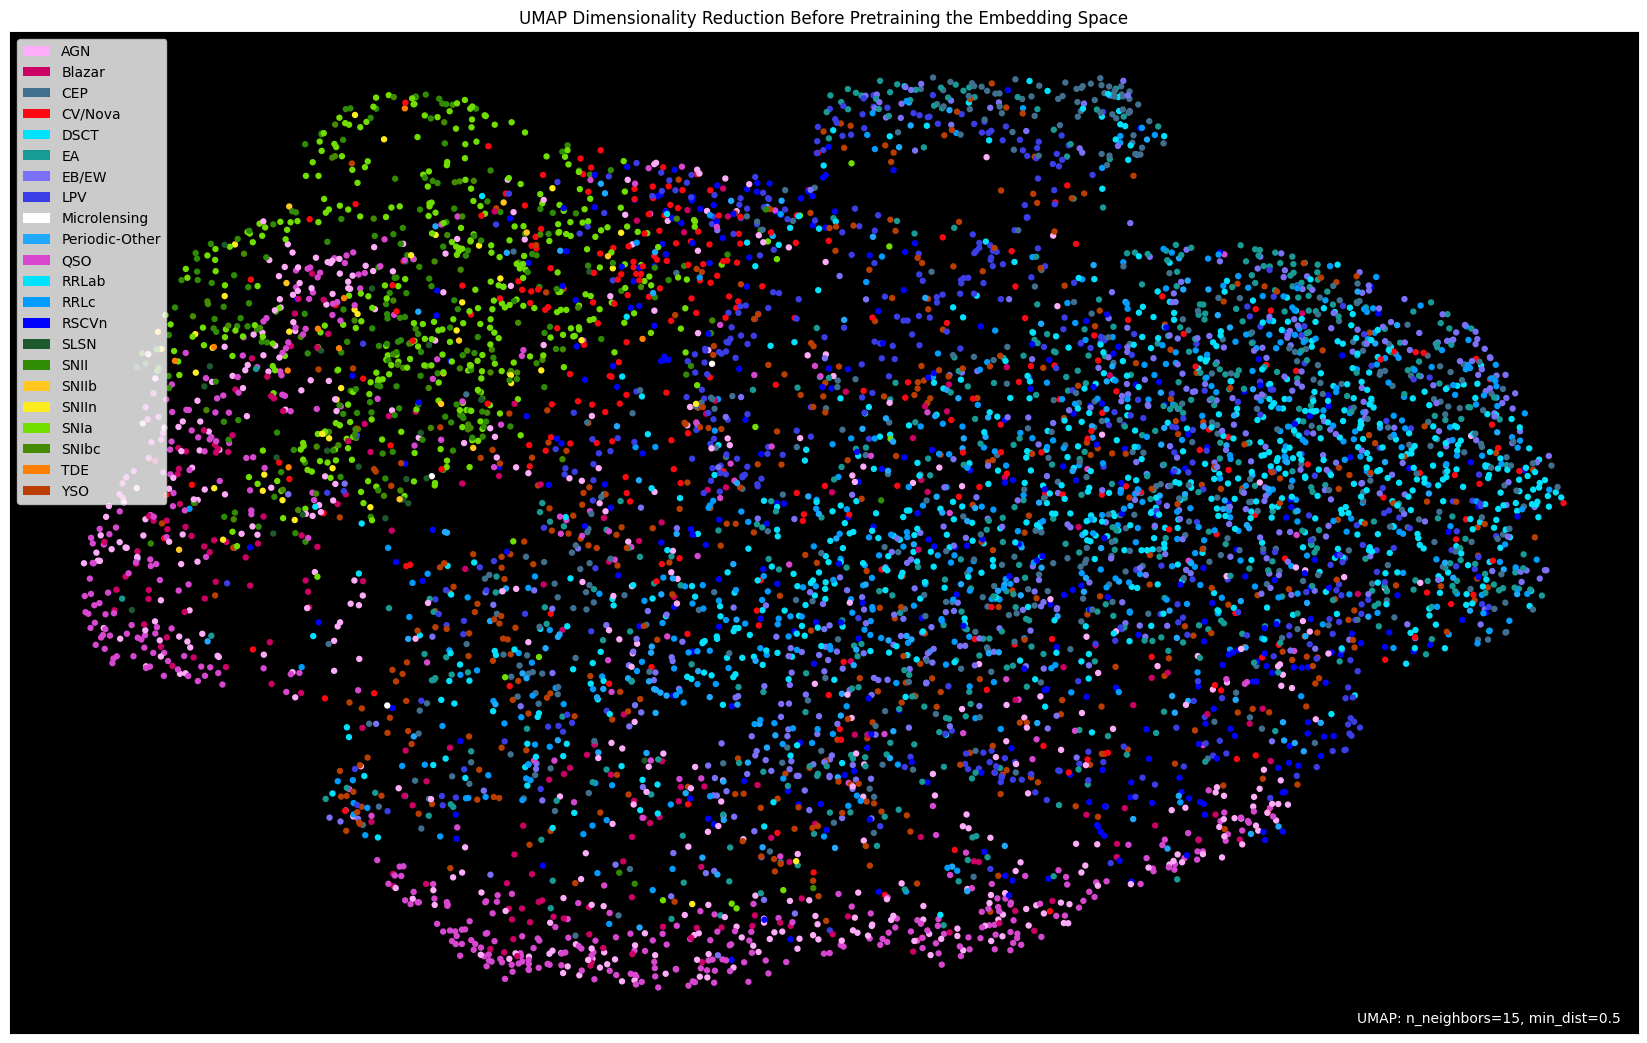

In [162]:
import numpy as np

colors = [
    '#ffacfa',# agn
     "#cd0066",#'#96034A', #blacar 8
      "#41708f", # cep 12
      "#FE0912", # cvnova 5
        '#00e3ff', #dsct 15
    "#189a95", # EA 2
 '#7a71f8', # ebew 10
   "#3b3ee7ff", #lpv 11
     "#FFFFFF", # microlensing 21
      '#1FA9FF', # periodic other 14
       '#D747CF', #qso 1
  '#00e3ff', # rrlab 13
    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
      "#1E5A2E", # slsn 17
       '#2F8B04', # snii 9
     '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
     '#70df00',  # snia 4
     "#458a00", # snibc 16
       "#ff8000", # tde 18
     "#bb3e00", #yso 3
    ]
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (21,13))
ax = fig.add_subplot(111)
plt.title('UMAP Dimensionality Reduction Before Pretraining the Embedding Space')
umap.plot.points(mapper, labels = np.array([{value:key for key, value in ZTF_TAXONOMY().items()}[i] for i in target.astype(int)]), height = 1080, width = 1920, background = 'black', color_key = colors, ax = ax)

<Axes: title={'center': 'UMAP Dimensionality Reduction for the Pretrained Embedding Space by Hierarchy Class'}>

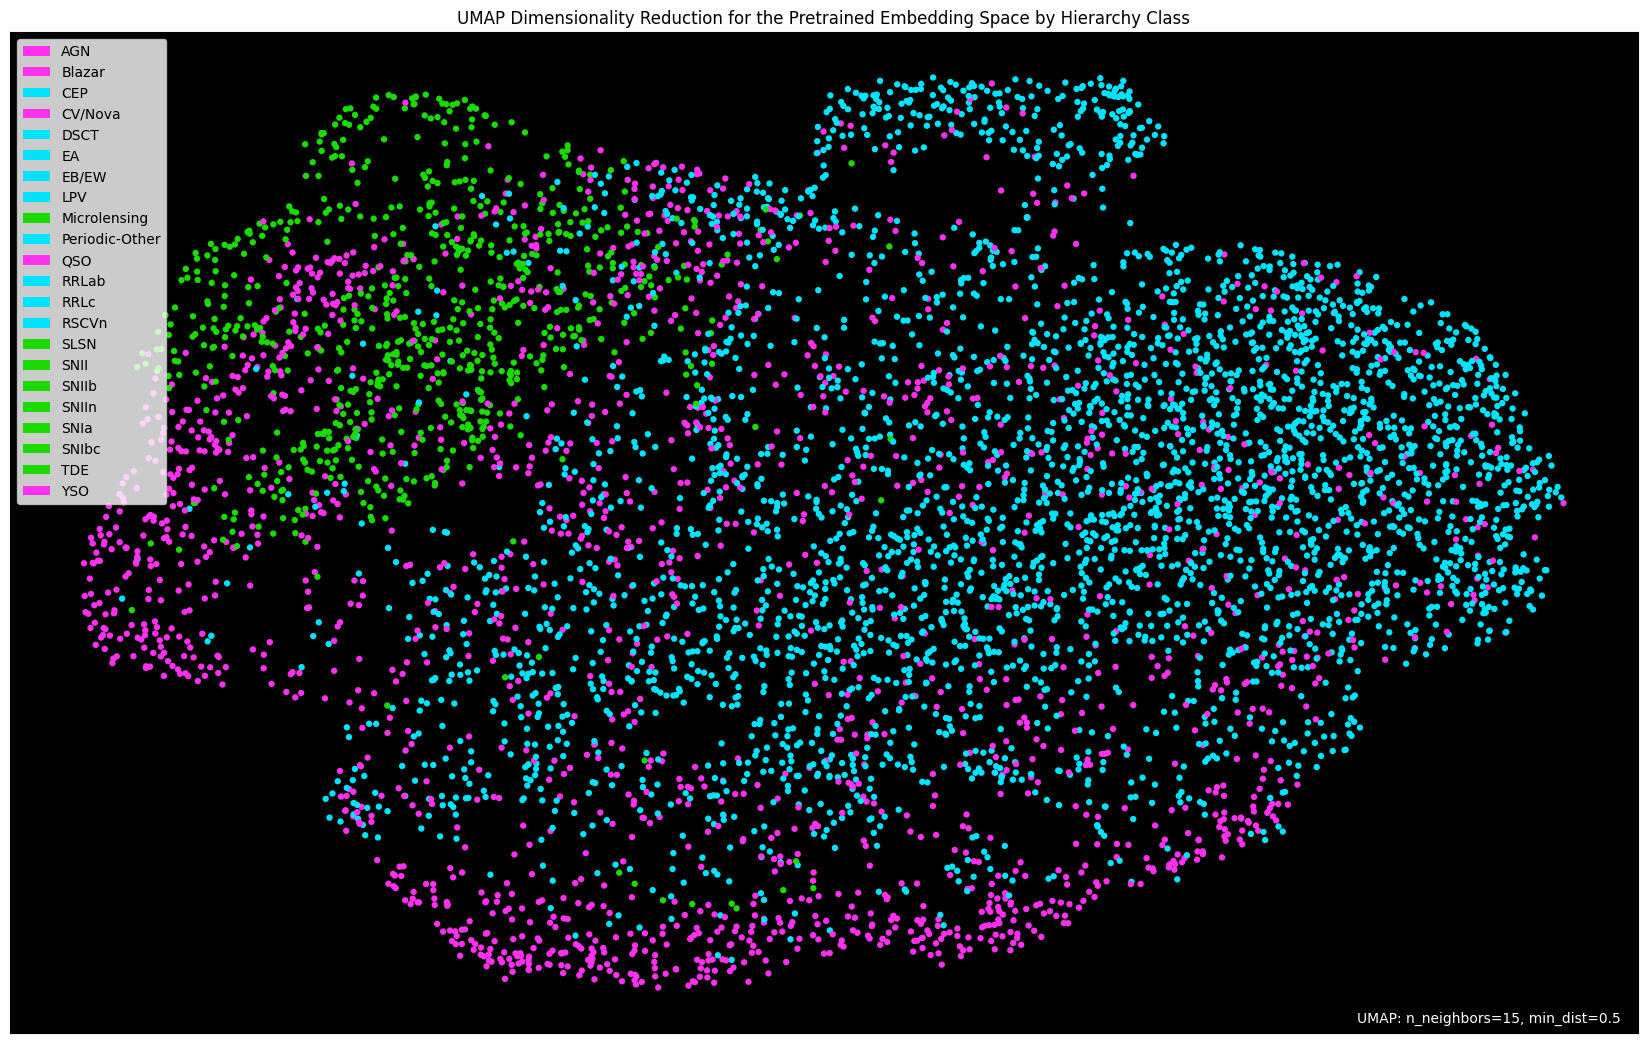

In [163]:

colors_hier = [
    '#fd31ee',# agn
    '#fd31ee', #qso 1

    '#00e3ff', # EA 2

    '#fd31ee', #yso 3

    '#00e3ff', # EA 2
     '#00e3ff',# 6 rrlc
     '#00e3ff',# 6 rrlc
     '#00e3ff',# 6 rrlc
    '#1bda00', # snii 9
    '#00e3ff',# 6 rrlc  tt

    '#fd31ee', # cvnova 5

    '#00e3ff',  # 7 rscvn
    '#00e3ff',  # 7 rscvn
    '#00e3ff',  # 7 rscvn
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
'#1bda00', # snii 9
 '#fd31ee', # cvnova 5

    ]
fig = plt.figure(figsize = (21,13))
ax = fig.add_subplot(111)
plt.title('UMAP Dimensionality Reduction for the Pretrained Embedding Space by Hierarchy Class')
umap.plot.points(mapper, labels = np.array([{value:key for key, value in ZTF_TAXONOMY().items()}[i] for i in target.astype(int)]), height = 1080, width = 1920, background = 'black', color_key = colors_hier, ax = ax)


In [164]:
colors = [
    '#ffacfa',# agn
    '#D747CF', #qso 1
    "#189a95", # EA 2

    "#bb3e00", #yso 3
    '#70df00',  # snia 4
    "#FE0912", # cvnova 5

    '#009cff',# 6 rrlc  tt
    "#0004ffff",  # 7 rscvn
    "#cd0066",#'#96034A', #blacar 8

    '#2F8B04', # snii 9
    '#7a71f8', # ebew 10
    "#3b3ee7ff", #lpv 11

    "#41708f", # cep 12
    '#00e3ff', # rrlab 13
    '#1FA9FF', # periodic other 14
     '#00e3ff', #dsct 15
    "#458a00", # snibc 16
    "#1E5A2E", # slsn 17
    "#ff8000", # tde 18

    '#FFC71F', # sniib 19
    '#FFEC1F', # sniin 20
    "#FFFFFF", # microlensing 21
    ]
umap.plot.output_notebook()
p = umap.plot.interactive(mapper,
    labels=target,
    hover_data=hover_data,
    point_size=3,
    tools=["pan","wheel_zoom",
    "box_zoom","save",
    "reset","box_select"],
    width=1920,
    height=1080,
    #theme = 'fire',
    #color_key = colors_hier,
    color_key = colors,
    background = 'black', #midnightblue',
    alpha = 0.9)
umap.plot.show(p)

Loading BokehJS ...

In [165]:
#dl.set_sampler(True)
dl.init_train_dataset()
X_train, y_train =test.predict(dl.train_dataset, DEVICE)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:2888: RuntimeWarning: invalid value encountered in subtract
  np.interp(X_col_finite, quantiles, self.references_)


device set to cuda:2


100%|██████████| 1525/1525 [00:55<00:00, 27.47it/s]


In [166]:
class_sampler_count  = [1783,1804,1785,1526,1566,1008,1855,1440,872,891,1858,1860,1814,1876,763,973,278,121,56,70,172,17]

weights_dict = {float(i): 1/class_sampler_count[i] for i in range(len(class_sampler_count))}

In [167]:
from sklearn.metrics import classification_report
train_preds, val_preds = test.compute_logistic_regressor(X_train, y_train, X_val, y_val, ZTF_TAXONOMY,weights = weights_dict)

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [168]:
0.2489,0.2430,0.2438,0.2454,

(0.2489, 0.243, 0.2438, 0.2454)

                precision    recall  f1-score   support

           AGN     0.2680    0.1174    0.1633       443
           QSO     0.4786    0.5849    0.5264       477
            EA     0.4545    0.4242    0.4389       495
           YSO     0.2785    0.1564    0.2003       422
          SNIa     0.4769    0.3307    0.3906       375
       CV/Nova     0.3333    0.3469    0.3400       271
          RRLc     0.3512    0.2593    0.2984       455
         RSCVn     0.2034    0.0710    0.1053       338
        Blazar     0.1883    0.2905    0.2285       210
          SNII     0.4103    0.0777    0.1306       206
         EB/EW     0.3873    0.3642    0.3754       453
           LPV     0.4891    0.7380    0.5883       458
           CEP     0.4545    0.1893    0.2673       449
         RRLab     0.4517    0.4778    0.4644       450
Periodic-Other     0.1632    0.1566    0.1598       198
          DSCT     0.1828    0.3678    0.2442       242
         SNIbc     0.1161    0.1970    0.1461  

<Axes: title={'center': 'logit reg: validation | macro f1: 0.242'}, xlabel='Predicted label', ylabel='True label'>

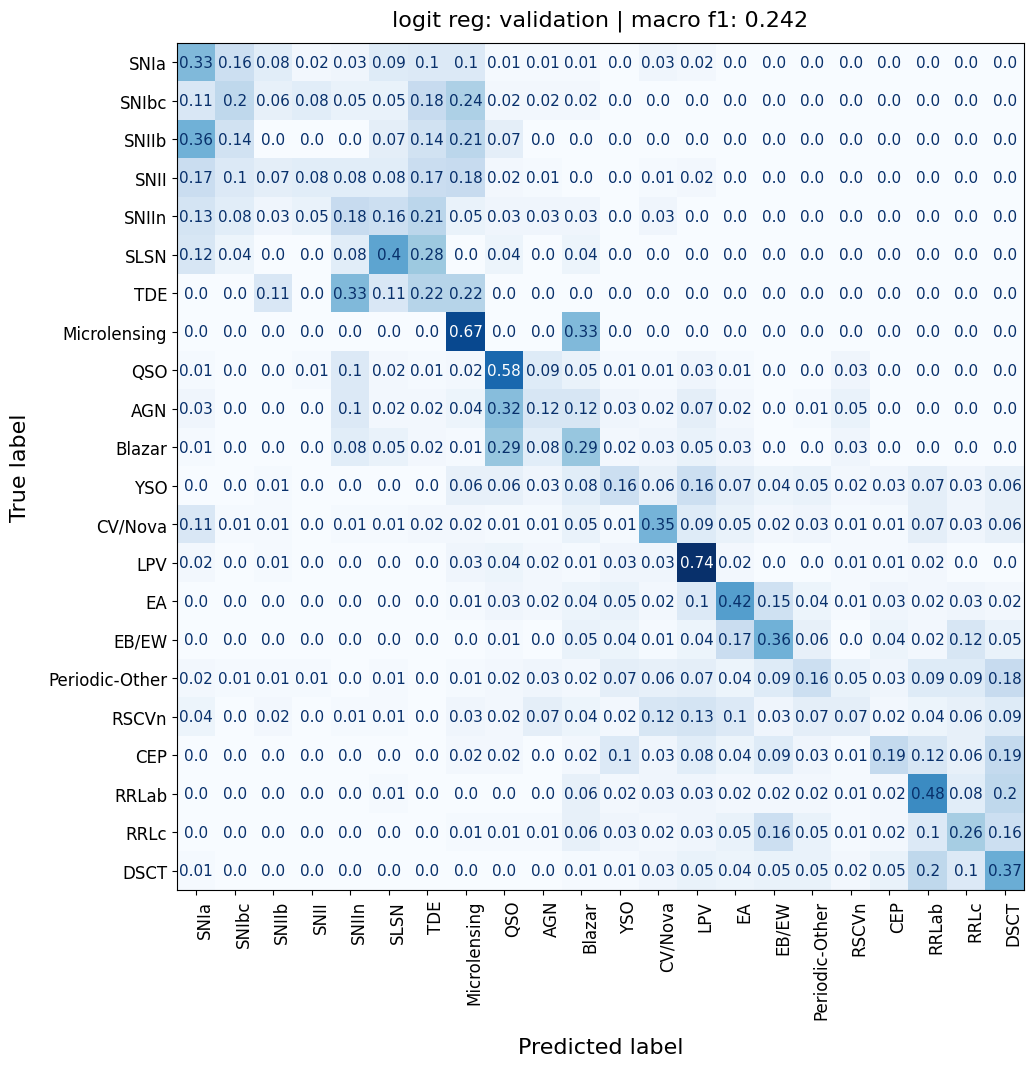

In [169]:
print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))
test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

                precision    recall  f1-score   support

           AGN     0.3692    0.4492    0.4053       443
           QSO     0.5408    0.5975    0.5677       477
            EA     0.5575    0.6364    0.5943       495
           YSO     0.3980    0.3744    0.3858       422
          SNIa     0.5443    0.8187    0.6539       375
       CV/Nova     0.6393    0.4317    0.5154       271
          RRLc     0.3538    0.5692    0.4364       455
         RSCVn     0.3755    0.2722    0.3156       338
        Blazar     0.3529    0.1714    0.2308       210
          SNII     0.4094    0.3398    0.3714       206
         EB/EW     0.4275    0.4945    0.4585       453
           LPV     0.7801    0.8057    0.7927       458
           CEP     0.5559    0.4432    0.4932       449
         RRLab     0.5009    0.5867    0.5404       450
Periodic-Other     0.0943    0.0253    0.0398       198
          DSCT     0.3196    0.1281    0.1829       242
         SNIbc     0.1053    0.0303    0.0471  

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

<Axes: title={'center': 'logit reg: validation | macro f1: 0.3293'}, xlabel='Predicted label', ylabel='True label'>

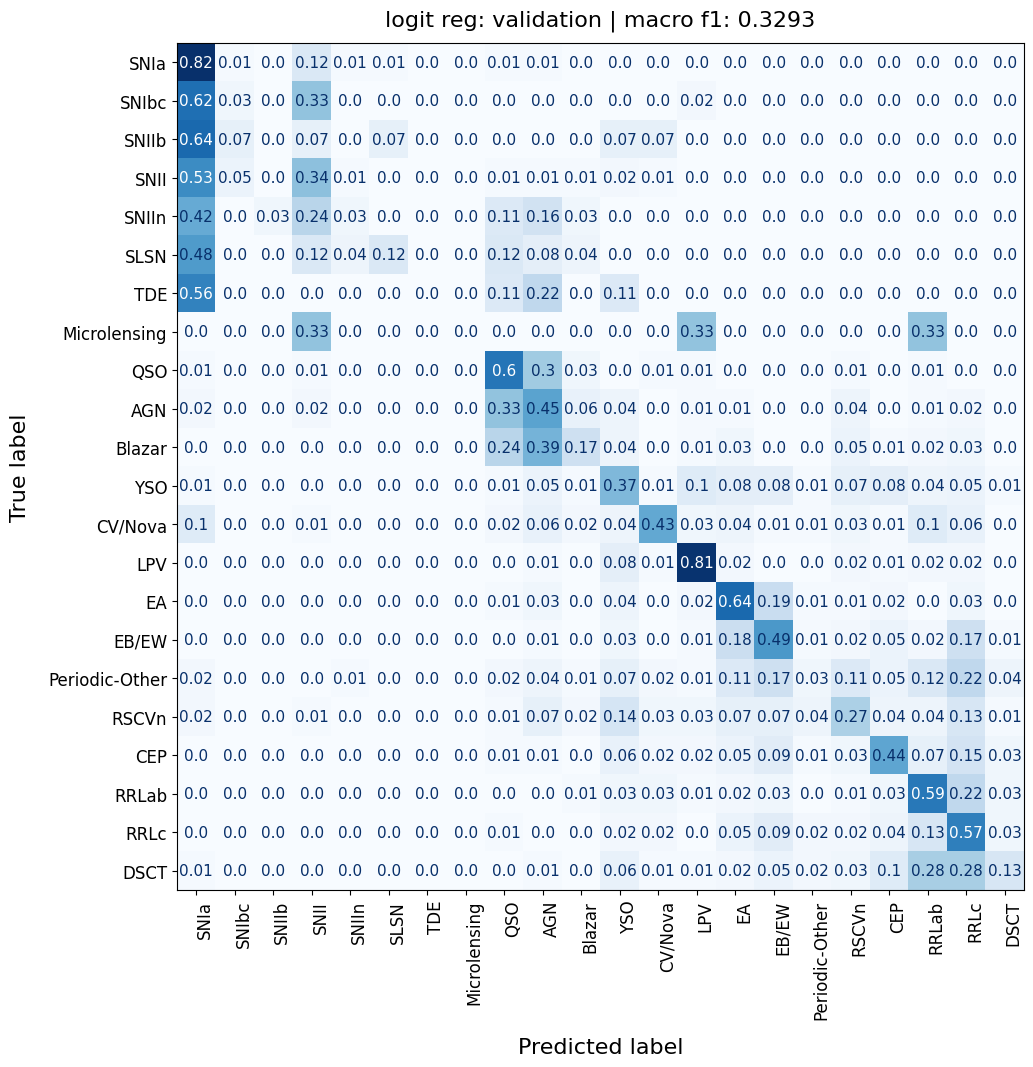

In [170]:
train_preds, val_preds = test.compute_knn(X_train, y_train, X_val, y_val, ZTF_TAXONOMY)
print(classification_report(y_val,val_preds, target_names=list(TAXONOMY().keys()),digits = 4))
test.get_confusion_matrix(val_preds, y_val, ZTF_TAXONOMY, dataset_type = 'validation')

In [171]:
#print(classification_report(y_train,train_preds, target_names=list(TAXONOMY().keys()),digits = 4))

In [172]:
asdf

NameError: name 'asdf' is not defined

In [ ]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

model1 = Pipeline([
            ('scaler', StandardScaler()),  # z = (x - mean) / std
            ('model', LogisticRegression(random_state=0, max_iter = 1000, multi_class = 'ovr', class_weight=weights_dict))
        ])
model2 =  Pipeline([
            ('scaler', StandardScaler()),  # z = (x - mean) / std
             ('model', KNeighborsClassifier(n_neighbors=15,weights='uniform'))
        ])

ensemble = VotingClassifier(estimators=[
    ('lr', model1),
    #('rf', model3),
('model', model2)
], voting='soft')
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_val)

print(classification_report(y_val,y_pred, target_names=list(TAXONOMY().keys()),digits = 4))

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


                precision    recall  f1-score   support

           AGN     0.2956    0.2709    0.2827       443
           QSO     0.5122    0.6625    0.5777       477
            EA     0.4906    0.4727    0.4815       495
           YSO     0.3773    0.2441    0.2964       422
          SNIa     0.4961    0.8427    0.6245       375
       CV/Nova     0.5036    0.2546    0.3382       271
          RRLc     0.2997    0.4176    0.3489       455
         RSCVn     0.2315    0.2041    0.2170       338
        Blazar     0.2614    0.1095    0.1544       210
          SNII     0.4286    0.3495    0.3850       206
         EB/EW     0.3657    0.4901    0.4189       453
           LPV     0.5197    0.5764    0.5466       458
           CEP     0.3689    0.2851    0.3216       449
         RRLab     0.4046    0.5422    0.4634       450
Periodic-Other     0.1600    0.0606    0.0879       198
          DSCT     0.2273    0.1653    0.1914       242
         SNIbc     0.2105    0.0606    0.0941  

/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr